# 21 - Fundamental Algorithms for Nonlinear Products

This notebook is a standalone, executable replacement for Chapter 21 of *Geometric Algebra for Computer Science*. The source span was checked before writing: PDF extraction pages 549-560 correspond to the printed textbook pages 529-540. The explanations here are original study notes, not copied textbook prose, and the computations are small enough to inspect directly.

Chapter 21 is where implementation stops being a product table problem. Linear products can be distributed over coordinates, then reduced to loops over basis blades. Nonlinear products ask for something more structural: Is this object a versor? Does this blade have a stable factorization? Which factors are shared by two blades, and which are present in exactly one of them? Can we decide that robustly when the coordinates are almost degenerate? The notebook answers those questions with a compact Euclidean coordinate engine and several visual diagnostics.


## The Chapter Idea In One Picture

The core implementation move is to avoid treating every nonlinear operation as a dense black-box multivector calculation. A blade, a versor, a meet, and a join all carry more structure than a raw coordinate array. If the implementation recognizes that structure, it can use faster and more reliable algorithms: a versor inverse is just a reverse divided by one scalar; a blade can be factored by recovering the subspace it spans; a delta product can predict the grades of a meet and join; and a meet/join routine can stop once it has found enough stable factors.

There is a useful tension running through the chapter. The formulas are coordinate-free, but a robust implementation needs numerical thresholds. A symbolic derivation might say that two planes share exactly one line. Floating point arithmetic says something more cautious: two principal angles look like one exact common direction and one nearly common direction, so the threshold decides whether the planes are different or almost the same. That is not a failure of geometric algebra. It is the reality of turning geometric predicates into code.

The picture we will keep in mind is two plane blades in three-dimensional Euclidean space. Their common factor is the meet line. Their union of factors is the join, which fills the ambient 3-space. The delta product collects the factors that are not shared. Those four objects let us test nearly every algorithmic idea in the chapter without needing a large implementation.


## Translation Guide

| Geometric idea | Implementation shadow in this notebook |
| --- | --- |
| Multivector | A dense NumPy array indexed by basis-blade bit masks. |
| Basis blade | An integer mask such as `0b011`, displayed as `e1e2`. |
| Reverse | Grade-dependent sign flip implemented coordinate by coordinate. |
| Versor inverse | `reverse(V) / scalar_part(V reverse(V))`, with a residual check that the denominator really is scalar. |
| Generic inverse | A left-multiplication matrix solve, useful for comparison but slower and less stable near singular inputs. |
| Blade factorization | Recover the vector subspace of a k-blade from the nullspace of `x wedge B`, then reconstruct the blade from orthonormal factors and a scale. |
| Delta product | The highest-grade part of the geometric product `A B`; it contains factors appearing in exactly one of the input blades. |
| Meet and join | Subspace intersection and span computed from factored blades, with grades checked against the delta-product prediction. |
| Robustness threshold | A deliberate tolerance that decides when a small projection, rejection, or singular-value gap should count as numerical noise. |

The helper module lives at `utils/chapter21_nonlinear_products.py`. It is intentionally local and inspectable. A production library would specialize many of these operations for a fixed model and fixed multivector types; here the point is to make the algorithmic structure visible.


## Notebook Route

1. Import the helper module and create stable artifact folders.
2. Build a small dense algebra so every coordinate operation is transparent.
3. Compare the fast versor inverse with a generic matrix inverse.
4. Factor a blade, reconstruct it, and reject a uniform-grade nonblade.
5. Use the delta product to predict meet and join grades.
6. Compute and visualize the meet and join of two plane blades.
7. Stress the algorithm with nearly coincident planes and threshold choices.
8. Run final sanity checks, including artifact existence checks.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_DIR = BOOK_ROOT / "artifacts" / "chapter-21"
for slug in ["inverse", "factorization", "delta-product", "meet-join", "robustness", "sanity"]:
    (ARTIFACT_DIR / slug).mkdir(parents=True, exist_ok=True)

from utils.chapter21_nonlinear_products import (
    OrthonormalAlgebra,
    blade_from_vectors,
    delta_product,
    delta_set_figure,
    factor_blade,
    factorization_bar_figure,
    meet_join_figure,
    meet_join_from_blades,
    meet_join_grades,
    multivector_inverse_via_matrix,
    orthonormal_rows,
    robustness_scan,
    robustness_scan_figure,
    sanity_checks,
    subspace_containment_error,
    versor_from_vectors,
    versor_inverse,
)

np.set_printoptions(precision=5, suppress=True)
artifact_files: dict[str, Path] = {}


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


print(f"Project root: {BOOK_ROOT}")
print(f"Chapter artifacts: {rel(ARTIFACT_DIR)}")


Project root: D:\Geometry\Geometric-Algebra-for-Computer-Science
Chapter artifacts: artifacts/chapter-21


## Shared Algebra Helpers

The dense coordinate model below is deliberately modest. It assumes an orthonormal metric, stores all multivectors as arrays of length `2**n`, and multiplies basis blades by bit-mask reordering. That is enough for this chapter because the algorithms are the lesson, not a high-performance runtime. The important detail is that the nonlinear functions are not hidden behind a library call. You can inspect the helper and see exactly where grade projection, reversion, nullspace extraction, and principal-angle tests enter.

The examples use `E3` for most geometry and `E4` for one diagnostic: a grade-2 multivector that is uniform in grade but is not a simple blade. That example is a useful antidote to a tempting implementation shortcut. A blade is not merely a multivector with one occupied grade. It must be factorable as an outer product of vectors.


In [2]:
E3 = OrthonormalAlgebra((1.0, 1.0, 1.0), names=("e1", "e2", "e3"))
E4 = OrthonormalAlgebra((1.0, 1.0, 1.0, 1.0), names=("e1", "e2", "e3", "e4"))

print("E3 dense coordinate order:")
print(E3.blade_names)

sample = E3.scalar(1.0) + 0.25 * E3.vector([1.0, -2.0, 0.5])
print("sample multivector:", E3.format_multivector(sample))
print("grade norms:", E3.grade_norms(sample))


E3 dense coordinate order:
['1', 'e1', 'e2', 'e1e2', 'e3', 'e1e3', 'e2e3', 'e1e2e3']
sample multivector: 1 + 0.25 e1 - 0.5 e2 + 0.125 e3
grade norms: {0: 1.0, 1: 0.57282196186948, 2: 0.0, 3: 0.0}


## Worked Example: Fast Inverses For Versors

The inverse of a general multivector is a nonlinear operation. One possible implementation builds the matrix for left multiplication by the multivector and solves a linear system. That is conceptually broad, but it is also expensive and can be poorly conditioned.

Versors give us a better path. A versor is a geometric product of invertible vectors. Because reversion reverses the order of those vector factors, `V reverse(V)` collapses to a scalar product of vector squares. The inverse is therefore `reverse(V)` divided by that scalar. A robust implementation should still check the scalar collapse: if the non-scalar residual is not tiny, the input should not be treated as a versor by this fast path.

The cell below constructs a two-vector versor, verifies the fast inverse, then compares it with a generic multivector inverse. The generic inverse is useful as a fallback and as a teaching tool, but the condition number reminds us why Chapter 21 cares about specialized algorithms.


In [3]:
versor_factors = np.array(
    [
        [1.2, -0.3, 0.4],
        [0.2, 1.1, -0.5],
    ],
    dtype=float,
)
V = versor_from_vectors(E3, versor_factors)
V_inv = versor_inverse(E3, V)
identity_error = np.linalg.norm(E3.geometric_product(V, V_inv.inverse) - E3.scalar(1.0))

A = E3.scalar(0.9)
A += 0.35 * E3.vector([1.0, -0.4, 0.2])
A += np.array([0, 0, 0, 0.18, 0, -0.12, 0.07, 0.15], dtype=float)
trial_reverse = versor_inverse(E3, A, require_scalar=False)
trial_identity_error = np.linalg.norm(E3.geometric_product(A, trial_reverse.inverse) - E3.scalar(1.0))
matrix_inverse = multivector_inverse_via_matrix(E3, A)

inverse_report = {
    "versor": E3.format_multivector(V),
    "versor_denominator": V_inv.denominator,
    "versor_scalar_residual": V_inv.scalar_residual,
    "versor_identity_error": identity_error,
    "generic_reverse_trial_identity_error": trial_identity_error,
    "generic_matrix_condition_number": matrix_inverse.condition_number,
    "generic_matrix_identity_error": matrix_inverse.identity_error,
}
path = ARTIFACT_DIR / "inverse" / "inverse-diagnostics.json"
path.write_text(json.dumps(inverse_report, indent=2), encoding="utf-8")
artifact_files["inverse_diagnostics"] = path

print(json.dumps(inverse_report, indent=2))
print("artifact:", rel(path))


{
  "versor": "-0.29 + 1.38 e1e2 - 0.68 e1e3 - 0.29 e2e3",
  "versor_denominator": 2.535,
  "versor_scalar_residual": 6.938893903907228e-17,
  "versor_identity_error": 1.3877787807814457e-17,
  "generic_reverse_trial_identity_error": 0.7070545927586168,
  "generic_matrix_condition_number": 2.4139616060963727,
  "generic_matrix_identity_error": 4.819909745438293e-17
}
artifact: artifacts/chapter-21/inverse/inverse-diagnostics.json


## Blade Factorization

A blade is a subspace with orientation and scale. When it is stored additively as coordinates, the vector factors are no longer explicit. Chapter 21's factorization problem is to recover enough vector factors to use the blade in algorithms that want vector-level operations.

The helper uses a clean numerical characterization: for a k-blade `B`, a vector `x` lies in its represented subspace exactly when `x wedge B` vanishes. Therefore the subspace can be recovered as the nullspace of the linear map `x -> x wedge B`. Once we have an orthonormal row basis for that nullspace, we expand those factors back into a unit blade and compute the single scale that best reconstructs the original coordinates.

This is not the only possible factorization strategy, and it is not claiming production speed. Its virtue is inspectability. It also exposes a crucial distinction: the recovered factors can be orthonormal and unit length while the blade's scale lives separately. That separation is often the cleanest way to pass a factored blade to later algorithms.


original blade: 3.025 e1e2 + 4.2281 e1e3 + 6.5519 e2e3
reconstructed: 3.025 e1e2 + 4.2281 e1e3 + 6.5519 e2e3
grade: 2
scale: 8.363894549266508
factors as orthonormal rows:
 [[-0.36167  0.10252  0.92665]
 [-0.50552 -0.8567  -0.10252]]
relative reconstruction residual: 3.561786875710674e-16
artifact: artifacts/chapter-21/factorization/blade-reconstruction.png


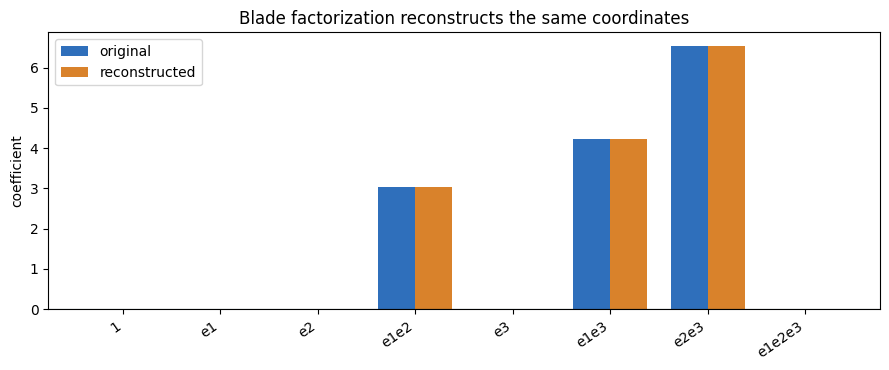

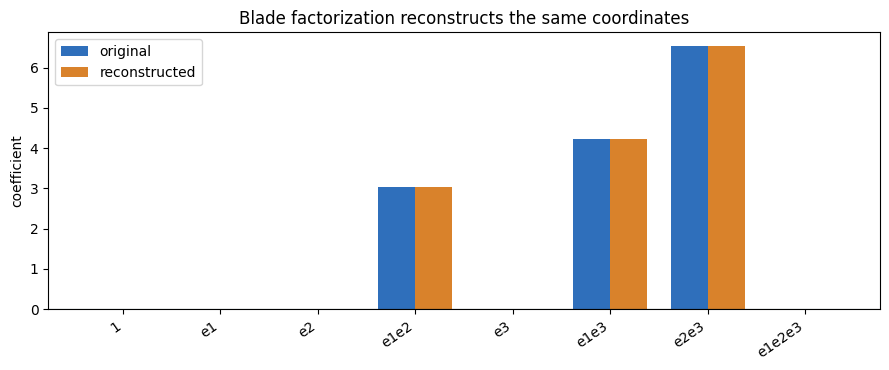

In [4]:
raw_factors = np.array(
    [
        [1.0, 1.8, 0.35],
        [-0.25, 0.65, 1.45],
    ]
)
B = 2.75 * blade_from_vectors(E3, raw_factors)
factored = factor_blade(E3, B)

fig = factorization_bar_figure(E3, B, factored.reconstructed)
path = ARTIFACT_DIR / "factorization" / "blade-reconstruction.png"
fig.savefig(path, dpi=160)
artifact_files["factorization_bar"] = path

print("original blade:", E3.format_multivector(B))
print("reconstructed:", E3.format_multivector(factored.reconstructed))
print("grade:", factored.grade)
print("scale:", factored.scale)
print("factors as orthonormal rows:\n", factored.factors)
print("relative reconstruction residual:", factored.residual)
print("artifact:", rel(path))
fig


## Factorization Is A Real Test

A common mistake is to classify a blade by grade alone. The grade test is necessary, but it is not sufficient. The sum `e1e2 + e3e4` in four-dimensional Euclidean space is a pure grade-2 multivector, yet it does not describe one 2-plane. It describes two independent coordinate-plane pieces added together. A factorization routine should refuse to produce two vector factors for it.

The next cell pairs two checks. First it applies a versor sandwich to basis vectors and confirms that the result stays grade-1. That is the operational reason versors are geometric transformations. Second it asks the blade factorizer to process the non-simple grade-2 example. The expected result is a controlled failure, not a plausible-looking but wrong factor list.


In [5]:
for index in range(E3.dimension):
    basis_vector = E3.basis_vector(index)
    transformed = E3.geometric_product(E3.geometric_product(V, basis_vector), V_inv.inverse)
    print(E3.names[index], "sandwich grade norms:", E3.grade_norms(transformed))

simple_e12 = blade_from_vectors(E4, [[1, 0, 0, 0], [0, 1, 0, 0]])
simple_e34 = blade_from_vectors(E4, [[0, 0, 1, 0], [0, 0, 0, 1]])
not_a_blade = simple_e12 + simple_e34
print("uniform-grade candidate:", E4.format_multivector(not_a_blade))
print("grade norms:", E4.grade_norms(not_a_blade))

try:
    factor_blade(E4, not_a_blade)
    nonblade_message = "unexpectedly factored"
except ValueError as exc:
    nonblade_message = f"factorization rejected it: {exc}"
print(nonblade_message)


e1 sandwich grade norms: {0: 0.0, 1: 1.0, 2: 0.0, 3: 1.3877787807814457e-17}
e2 sandwich grade norms: {0: 0.0, 1: 1.0, 2: 0.0, 3: 1.3877787807814457e-17}
e3 sandwich grade norms: {0: 0.0, 1: 1.0, 2: 0.0, 3: 0.0}
uniform-grade candidate: 1 e1e2 + 1 e3e4
grade norms: {0: 0.0, 1: 0.0, 2: 1.4142135623730951, 3: 0.0, 4: 0.0}
factorization rejected it: blade factorization did not find the expected subspace dimension; the input may not be a simple blade


## The Delta Product

The delta product is the chapter's bridge from products to incidence. For blades `A` and `B`, compute the geometric product `A B` and keep its highest nonzero grade. Shared factors cancel down through metric products; unshared factors survive in the top grade. That top-grade blade acts like the symmetric difference of factor sets.

For two planes in 3-space that share a line, each input has grade 2. Their delta product has grade 2 because one factor from each plane is not shared. From those three grades, the meet and join grades follow: `meet_grade = (a + b - delta_grade) / 2` and `join_grade = (a + b + delta_grade) / 2`. In this example that predicts a line meet and a 3-volume join.

The saved diagram is a set-style mnemonic. The yellow region is what appears in exactly one input; the green region is what appears in both. The algebraic delta product is not a Venn diagram, but the analogy is a good way to remember which factors it is measuring.


{
  "A": "1 e1e2",
  "B": "1 e1e3",
  "delta": "-1 e2e3",
  "delta_grade": 2,
  "predicted_meet_grade": 1,
  "predicted_join_grade": 3
}


artifact: artifacts/chapter-21/delta-product/delta-set-mnemonic.png


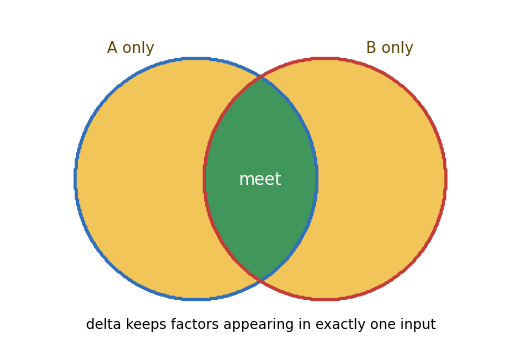

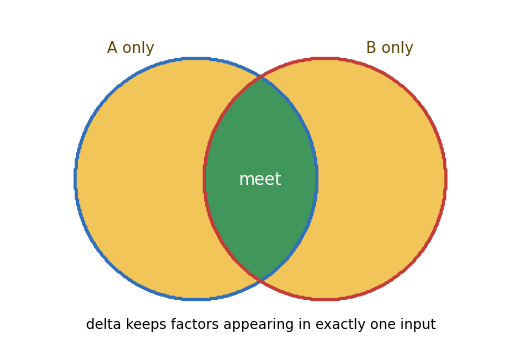

In [6]:
plane_a_factors = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
plane_b_factors = np.array([[1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])
A_plane = blade_from_vectors(E3, plane_a_factors)
B_plane = blade_from_vectors(E3, plane_b_factors)
D, delta_grade = delta_product(E3, A_plane, B_plane)
meet_grade, join_grade = meet_join_grades(2, 2, delta_grade)

fig = delta_set_figure()
path = ARTIFACT_DIR / "delta-product" / "delta-set-mnemonic.png"
fig.savefig(path, dpi=160)
artifact_files["delta_set"] = path

delta_report = {
    "A": E3.format_multivector(A_plane),
    "B": E3.format_multivector(B_plane),
    "delta": E3.format_multivector(D),
    "delta_grade": delta_grade,
    "predicted_meet_grade": meet_grade,
    "predicted_join_grade": join_grade,
}
print(json.dumps(delta_report, indent=2))
print("artifact:", rel(path))
fig


## Meet And Join Algorithm

The meet/join routine in the helper follows the spirit of the chapter while staying compact. It factors both input blades, computes the delta product to predict the target grades, then uses principal angles between the factor subspaces to identify common factors. The meet is the span of the common factors. The join is the orthonormal row span of all input factors. The final checks ask whether the computed meet lies inside both inputs and whether both input subspaces lie inside the join.

A full optimized implementation could use the delta-product dual and projection/rejection loops to stop as soon as either the meet or the join has been constructed. The point here is the same: do not expand every nonlinear question into a generic dense operation when the factor structure gives you a smaller route.


In [7]:
angle = np.deg2rad(58.0)
plane_a_factors = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
plane_b_factors = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(angle), np.sin(angle)]])
A_plane = blade_from_vectors(E3, plane_a_factors)
B_plane = blade_from_vectors(E3, plane_b_factors)
result = meet_join_from_blades(E3, A_plane, B_plane)

fig = meet_join_figure(plane_a_factors, plane_b_factors, result)
path = ARTIFACT_DIR / "meet-join" / "plane-meet-join.html"
fig.write_html(path, include_plotlyjs="cdn", full_html=True)
artifact_files["meet_join_html"] = path

meet_in_a = subspace_containment_error(result.meet_factors, plane_a_factors)
meet_in_b = subspace_containment_error(result.meet_factors, plane_b_factors)
a_in_join = subspace_containment_error(plane_a_factors, result.join_factors)
b_in_join = subspace_containment_error(plane_b_factors, result.join_factors)

print("singular values between plane factor spaces:", result.singular_values)
print("meet factors:\n", result.meet_factors)
print("join factors:\n", result.join_factors)
print("delta grade:", result.delta_grade)
print("predicted grades:", result.predicted_meet_grade, result.predicted_join_grade)
print("actual grades:", result.meet_factors.shape[0], result.join_factors.shape[0])
print("containment errors:", {"meet_in_a": meet_in_a, "meet_in_b": meet_in_b, "a_in_join": a_in_join, "b_in_join": b_in_join})
print("artifact:", rel(path))
fig


singular values between plane factor spaces: [1.      0.52992]
meet factors:
 [[1. 0. 0.]]
join factors:
 [[-1.      -0.       0.     ]
 [ 0.       0.87462  0.48481]
 [-0.      -0.48481  0.87462]]
delta grade: 2
predicted grades: 1 3
actual grades: 1 3
containment errors: {'meet_in_a': 0.0, 'meet_in_b': 0.0, 'a_in_join': 0.0, 'b_in_join': 0.0}
artifact: artifacts/chapter-21/meet-join/plane-meet-join.html


## Numerical Robustness

The most implementation-flavored part of the chapter is the warning about thresholds. A symbolic algorithm can say that a projection or rejection is zero. A numerical algorithm has to decide how small is small enough. If the threshold is too tight, noise is treated as geometry. If it is too loose, nearby but distinct factors are merged.

The scan below keeps one shared factor fixed and rotates the second factor of one plane toward the second factor of the other. The two principal cosines between the plane subspaces are `1` and `cos(angle)`. The value `1 - cos(angle)` is the gap that tells us whether the second direction should count as common. On a log-log plot, horizontal threshold lines become decision boundaries. Below a line, the planes may be classified as the same plane by that tolerance; above it, they remain distinct planes with a line meet.


[
  {
    "angle_degrees": 0.001,
    "sigma_1": 1.0,
    "sigma_2": 0.9999999998476914,
    "gap_from_common": 1.523086101684612e-10,
    "tol=1e-08": 2,
    "tol=1e-05": 2,
    "tol=0.001": 2
  },
  {
    "angle_degrees": 0.0140986923497486,
    "sigma_1": 1.0,
    "sigma_2": 0.9999999697251218,
    "gap_from_common": 3.0274878159985974e-08,
    "tol=1e-08": 1,
    "tol=1e-05": 2,
    "tol=0.001": 2
  },
  {
    "angle_degrees": 0.19877312597285968,
    "sigma_1": 1.0,
    "sigma_2": 0.999993982173822,
    "gap_from_common": 6.017826178039698e-06,
    "tol=1e-08": 1,
    "tol=1e-05": 2,
    "tol=0.001": 2
  },
  {
    "angle_degrees": 2.802441150489173,
    "sigma_1": 1.0,
    "sigma_2": 0.998804055136038,
    "gap_from_common": 0.0011959448639620174,
    "tol=1e-08": 1,
    "tol=1e-05": 1,
    "tol=0.001": 1
  },
  {
    "angle_degrees": 39.51075560902235,
    "sigma_1": 1.0,
    "sigma_2": 0.7715051646864164,
    "gap_from_common": 0.2284948353135836,
    "tol=1e-08": 1,
    "tol=1

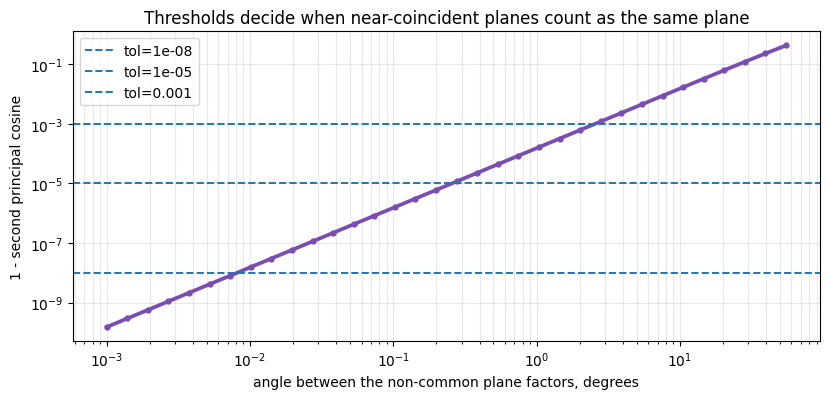

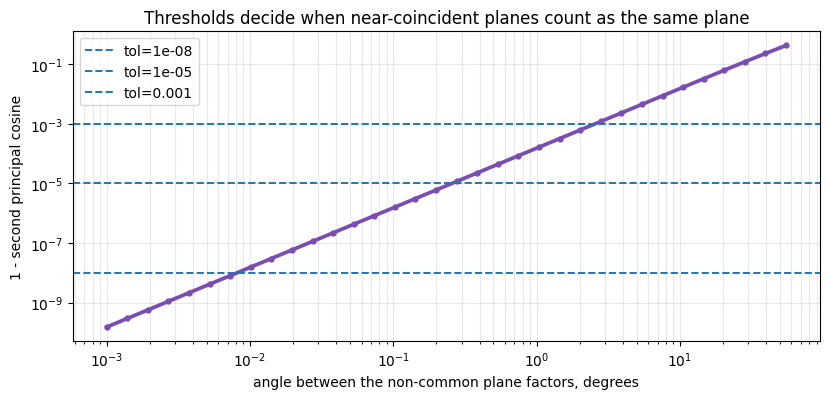

In [8]:
angles = np.geomspace(0.001, 55.0, 34)
rows = robustness_scan(angles)
thresholds = [1e-8, 1e-5, 1e-3]
fig = robustness_scan_figure(rows, thresholds)
path = ARTIFACT_DIR / "robustness" / "principal-angle-thresholds.png"
fig.savefig(path, dpi=160)
artifact_files["robustness_scan"] = path

sample_rows = []
for row in rows[::8]:
    decisions = {f"tol={tol:g}": int(1 + (row["gap_from_common"] <= tol)) for tol in thresholds}
    sample_rows.append({**row, **decisions})
print(json.dumps(sample_rows, indent=2))
print("artifact:", rel(path))
fig


## Applied Lab: A Threshold-Aware Meet

A notebook replacement should not only show the happy path. The lab below creates three increasingly tiny angles between two planes and asks the meet/join routine what it sees under three tolerances. The expected behavior is not one universal answer. The answer depends on the tolerance because the input itself is asking a numerical question: are these two factors genuinely different, or are they the same factor perturbed by coordinate noise?

This is the right mental model for interactive geometry programs. Handles, mouse rays, camera transforms, and intersections rarely arrive as exact algebraic objects. The algorithm should carry a tolerance as part of its contract, and tests should cover the transition zone rather than only exact textbook configurations.


In [9]:
lab_angles = [1e-4, 1e-2, 1.0]
lab_tolerances = [1e-10, 1e-6, 1e-3]
lab_rows = []
for angle_degrees in lab_angles:
    theta = np.deg2rad(angle_degrees)
    left = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
    right = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(theta), np.sin(theta)]])
    left_blade = blade_from_vectors(E3, left)
    right_blade = blade_from_vectors(E3, right)
    for tolerance in lab_tolerances:
        mj = meet_join_from_blades(E3, left_blade, right_blade, common_tol=tolerance)
        lab_rows.append(
            {
                "angle_degrees": angle_degrees,
                "common_tol": tolerance,
                "singular_values": [float(value) for value in mj.singular_values],
                "actual_meet_grade": int(mj.meet_factors.shape[0]),
                "actual_join_grade": int(mj.join_factors.shape[0]),
            }
        )

path = ARTIFACT_DIR / "robustness" / "threshold-lab.json"
path.write_text(json.dumps(lab_rows, indent=2), encoding="utf-8")
artifact_files["threshold_lab"] = path
print(json.dumps(lab_rows, indent=2))
print("artifact:", rel(path))


[
  {
    "angle_degrees": 0.0001,
    "common_tol": 1e-10,
    "singular_values": [
      1.0000000000000002,
      0.9999999999984772
    ],
    "actual_meet_grade": 2,
    "actual_join_grade": 3
  },
  {
    "angle_degrees": 0.0001,
    "common_tol": 1e-06,
    "singular_values": [
      1.0000000000000002,
      0.9999999999984772
    ],
    "actual_meet_grade": 2,
    "actual_join_grade": 3
  },
  {
    "angle_degrees": 0.0001,
    "common_tol": 0.001,
    "singular_values": [
      1.0000000000000002,
      0.9999999999984772
    ],
    "actual_meet_grade": 2,
    "actual_join_grade": 3
  },
  {
    "angle_degrees": 0.01,
    "common_tol": 1e-10,
    "singular_values": [
      1.0000000000000002,
      0.9999999847691291
    ],
    "actual_meet_grade": 1,
    "actual_join_grade": 3
  },
  {
    "angle_degrees": 0.01,
    "common_tol": 1e-06,
    "singular_values": [
      1.0000000000000002,
      0.9999999847691291
    ],
    "actual_meet_grade": 2,
    "actual_join_grade": 3
  

## Sanity Checks

The last cell is intentionally strict. It checks algebraic invariants and artifact existence in one place. The invariant checks are small: factorization reconstructs its blade, a versor multiplied by its fast inverse returns the scalar identity, the delta product predicts the same meet and join grades that the subspace computation finds, and the meet is contained in both inputs. The artifact checks ensure that the notebook did not merely display transient outputs; it wrote stable files under `artifacts/chapter-21`.


In [10]:
checks = sanity_checks()

assert checks["factorization_residual"] < 1e-8
assert checks["versor_inverse_identity_error"] < 1e-8
assert checks["delta_grade"] == 2.0
assert checks["predicted_meet_grade"] == checks["actual_meet_grade"] == 1.0
assert checks["predicted_join_grade"] == checks["actual_join_grade"] == 3.0
assert checks["meet_containment_error"] < 1e-8

for label, path in artifact_files.items():
    assert path.exists(), f"missing artifact {label}: {path}"
    assert ARTIFACT_DIR in path.parents, f"artifact escaped chapter directory: {path}"

report = {
    "checks": checks,
    "artifacts": {label: rel(path) for label, path in sorted(artifact_files.items())},
    "verified_source_span": "printed pp. 529-540; PDF extraction pages 549-560",
}
path = ARTIFACT_DIR / "sanity" / "sanity-report.json"
path.write_text(json.dumps(report, indent=2), encoding="utf-8")
artifact_files["sanity_report"] = path
assert path.exists()

print(json.dumps(report, indent=2))
print("sanity report:", rel(path))


{
  "checks": {
    "factorization_residual": 1.6653345352724009e-16,
    "versor_inverse_identity_error": 2.7755575615628914e-17,
    "delta_grade": 2.0,
    "predicted_meet_grade": 1.0,
    "predicted_join_grade": 3.0,
    "actual_meet_grade": 1.0,
    "actual_join_grade": 3.0,
    "meet_containment_error": 0.0
  },
  "artifacts": {
    "delta_set": "artifacts/chapter-21/delta-product/delta-set-mnemonic.png",
    "factorization_bar": "artifacts/chapter-21/factorization/blade-reconstruction.png",
    "inverse_diagnostics": "artifacts/chapter-21/inverse/inverse-diagnostics.json",
    "meet_join_html": "artifacts/chapter-21/meet-join/plane-meet-join.html",
    "robustness_scan": "artifacts/chapter-21/robustness/principal-angle-thresholds.png",
    "threshold_lab": "artifacts/chapter-21/robustness/threshold-lab.json"
  },
  "verified_source_span": "printed pp. 529-540; PDF extraction pages 549-560"
}
sanity report: artifacts/chapter-21/sanity/sanity-report.json


## Chapter Takeaways

Nonlinear geometric algebra algorithms are structure recovery algorithms. The dense coordinate array is still the storage format, but the computation asks what kind of object the array represents. If it is a versor, reverse-over-scalar inversion is the right tool. If it is a blade, factorization turns additive coordinates back into vector factors. If two blades are being compared, the delta product reveals how many factors are shared and how many belong to only one input.

The practical lesson is that correctness and robustness live together. A mathematically elegant meet/join derivation still needs thresholds, residual checks, and tests around near-degenerate inputs. The implementation should report when a fast path is justified, when a generic fallback is being used, and when the input is too ambiguous to classify cleanly. That is the difference between a notebook formula and a usable geometry kernel.
